##### Feladat (Példatár 1.2)

Egy $20 ~\mathrm{mm}$  átmérőjű acél rudat az ábra szerinti $50 ~\mathrm{kN}$  nagyságú erő terheli körkörösen a $B$ keresztmetszetben, valamint a $40 ~\mathrm{kN}$ 
nagyságú erő a $C$ keresztmetszetben. Az acél rugalmassági modulusza $200 ~\mathrm{GPa}$ .

Feladatok:

a) Rajzoljuk fel a normál igénybevételi ábrát.

b) Számítsuk ki a végkeresztmetszet elmozdulását.

c) Határozzuk meg az egyes szakaszokon ébredő feszültségeket.

<img src="img/01.jpg" alt="Feladat" width=300px>

##### Csomagok importálása

In [1]:
import numpy as np # Numerikus számítások
import matplotlib.pyplot as plt # Ábrázolás
plt.rcParams['mathtext.fontset'] = 'cm' # Betűtípus az ábrákon
plt.rcParams['font.family'] = 'serif' # Betűtípus az ábrákon
plt.rcParams['font.serif'] = ['cmr10'] # Betűtípus az ábrákon
plt.rcParams['axes.formatter.use_mathtext'] = True # Betűtípus az ábrákon
plt.rcParams['axes.unicode_minus'] = False # Betűtípus az ábrákon
from IPython.display import display, Math, Latex # Szép kimenet Jupyter notebookban
import sympy as sp # Szimbólikus számítások
from sympy import latex # Szép kimenet Jupyter notebookban
sp.init_printing() # Szép kimenet Jupyter notebookban

##### Adatok

In [2]:
L_1 = 600 # mm
L_2 = 400 # mm
d = 20 # mm
F_1 = 50 # kN
F_2 = 40 # kN
E = 200 # GPa

# Átváltás N, mm, MPa rendszerbe
F_1 = F_1*10**3 # N
F_2 = F_2*10**3 # N
E = E*10**3 # MPa

##### Szabadtest ábra

<img src="img/02.jpg" alt="Feladat" width=300px>

##### Ismeretlen erővektor

In [3]:
A_x = sp.Symbol('A_x')

##### Erőegyensúly

In [4]:
# x irány
eq = A_x - F_1 + F_2

A_xsol = sp.solve(eq, A_x)[0]
display(Math(rf'A_x = {latex(A_xsol)} ~\mathrm{{N}}'))

<IPython.core.display.Math object>

##### Normál igénybevétel

In [5]:
N_1 = -A_xsol
display(Math(rf'N_1 = {latex(N_1)} ~\mathrm{{N}}'))

N_2 = -A_xsol + F_1
display(Math(rf'N_2 = {latex(N_2)} ~\mathrm{{N}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

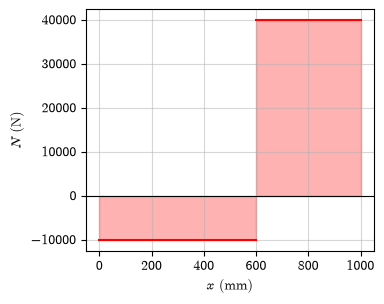

In [6]:
L_1n = float(L_1)
L_2n = float(L_2)
N_1n = float(N_1)
N_2n = float(N_2)

plt.figure(figsize=(10/2.54, 8/2.54))
plt.plot([0, L_1n], [N_1n, N_1n], color='red')
plt.fill_between([0, L_1n], [N_1n, N_1n], 0, color='red', alpha=0.3)
plt.plot([L_1n, L_1n+L_2n], [N_2n, N_2n], color='red')
plt.fill_between([L_1n, L_1n+L_2n], [N_2n, N_2n], 0, color='red', alpha=0.3)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel(r'$x ~ \mathrm{(mm)}$')
plt.ylabel(r'$N ~ \mathrm{(N)}$')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig('normal_igenybevetel.pdf')

##### A végkeresztmetszet elmozdulása

In [7]:
# A keresztmetszet mérete
A = d**2*sp.pi/4

# A keresztmetszet elmozdulása
deltaL = (N_1*L_1) / (A*E) + (N_2*L_2) / (A*E) 
display(Math(rf'\Delta L = \frac{{N_1 L_1}}{{A E}} + \frac{{N_2 L_2}}{{A E}}  = {latex(deltaL.evalf(4))} ~\mathrm{{mm}}'))

<IPython.core.display.Math object>

##### A részekben ébredő feszültségek

In [8]:
sigma_1 = N_1 / A
display(Math(rf'\sigma_1 = {latex(sigma_1.evalf(4))} ~\mathrm{{MPa}}'))

sigma_2 = N_2 / A
display(Math(rf'\sigma_2 = {latex(sigma_2.evalf(4))} ~\mathrm{{MPa}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>